<a href="https://colab.research.google.com/github/Rajeeb321123/Pytorch/blob/master/08_NLP_pytroch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to NLP Fundamental in Pytorch

NLP has the goal of deriving out of natural language ( could be sequence text or speech)

Another common term for NLP problems is sequence problem (seq2seq).

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
%%capture
!pip install -q "tqdm>=4.64.1"
!pip install mermaid-py
!pip install torchinfo
!pip install psutil

In [3]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import clear_output

# Import torchvision
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
device

PyTorch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


'cpu'

# Get Data

In [4]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 20.30 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.
PubMed_200k_RCT				       PubMed_20k_RCT_numbers_replaced_with_at_sign
PubMed_200k_RCT_numbers_replaced_with_at_sign  README.md
PubMed_20k_RCT


In [5]:
# Check what files are in the PubMed_20k Dataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/

dev.txt  test.txt  train.txt


In [6]:
# Start ou experiment using the 20k dataset with numbers replaced by "@" sign
data_dir = "/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [7]:
import os
os.listdir(data_dir)

['dev.txt', 'train.txt', 'test.txt']

In [8]:
# Check all of the filename in the target directory
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt']

#Visualize Data

In [9]:
# Create a function to read the line of a document
def get_lines(filename):
  """
  Reads filename (a text filename) and returns the lines of text as a lists.

  Args:
    filename:  a string containing the target filepath.

  Returns:
    A List of strings with one string per line from the target filename.
  """

  # with is simialr to try/finally
  with open(filename, "r") as f:
    return f.readlines()

In [10]:
# Let's read in the training lines
train_lines = get_lines(data_dir + "train.txt") # read the line for training file
train_lines[:28]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [11]:
len(train_lines)

210040

In [12]:
train_lines[20]

'METHODS\tAttentional biases for high caloric foods were measured by eye tracking during a visual probe task with pictorial food and neutral stimuli .\n'

In [13]:
"abc\ncd".replace("\n", "")

'abccd'

Let's think about how we want our data to look.

How I think our data would be represented?

```
[
  {
    'line_number': 0,
    'target': 'BACKGROUND',
    'text': Emotional eating is associated with overeating and the development of obesity .\n',
    'total_lines': 11
  },
  ...
]
```

In [14]:
len("tom\ttom".split("\t"))

2

In [15]:
train_lines[1]

'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n'

In [16]:
# very important to look at the train_lines in above to visualize the data and how it is formatted
def preprocess_text_with_line_numbers(filename):
  """
  Return a list of dictionaries of abstract line data.

  Takes in filename, reads it contents and sort through each line,
  extracting things like the target label, the text of sentence,
  how many sentences are in the current abstract and what sentence number the target line is.
  """

  input_lines = get_lines(filename) # get all lines from filename

  # abstract are separated by '/n' and '###24293578\n'
  abstract_lines = "" # create an empty abstract
  abstract_samples = [] # create and empty list of abstracts

  # Loop through each line in the target file
  for line in input_lines:

    # at the start of each abstract
    if line.startswith("###"): # check to see if the line is an ID line
      abstract_id = line
      abstract_lines = "" # reset the abstract string if the line is an ID line


    # the end of each abstract: we know we have '\n' at the end of each abstract (1 abstract: whole collection of background, methond, objective...)
    # elif line == '\n'
    elif line.isspace(): # means is it '\n' # check if the line is new line. if we reach end of the each line_number
      # now we again split line for each background, objective...
      # return list of each list
      abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines or it won string like ['hello i am Rajeeb', "todayis good day']"

      # Iterate thorugh each line in a single abstract and count them at the same time.
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # create an empty dictionary for each line
        target_text_split = abstract_line.split("\t") # split target label from text eg: [objective\tHello] ---> [objective, Hello]
        line_data["target"] = target_text_split[0] # get target label
        line_data["text"] = target_text_split[1].lower() # get target text and lower it # probably no need for lower for do it anyway.
        line_data["line_number"] = abstract_line_number # what number line does the line appear in the abstract
        line_data["total_lines"]  = len(abstract_line_split)-1 # how many total lines are there in target abstract (start from 0 i.e - 1)
        abstract_samples.append(line_data) # add line data to abstract sample list

    # if we are in BACKGROUND, or OBJECTIVE, OR REUSLTS .... (not at the start of abstract (###) or end ('\n') )
    else: # if the above condition aren't fulfilled the line contains a labelled sentence
      abstract_lines += line # adding whole element to abstract_lines so it can be formatted later in above elif condition when we reach the end of abstrac

  return abstract_samples


In [17]:
# Get data from file and preprocess it
%%time
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "dev.txt") # another txt file
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")

len(train_samples), len(val_samples), len(test_samples)

CPU times: user 654 ms, sys: 156 ms, total: 810 ms
Wall time: 1.22 s


(180040, 30212, 30135)

In [18]:
# Check the first abstract of our training data
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [19]:
import pandas as pd

train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(14)


,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [20]:
# Distribution of labels in training data
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


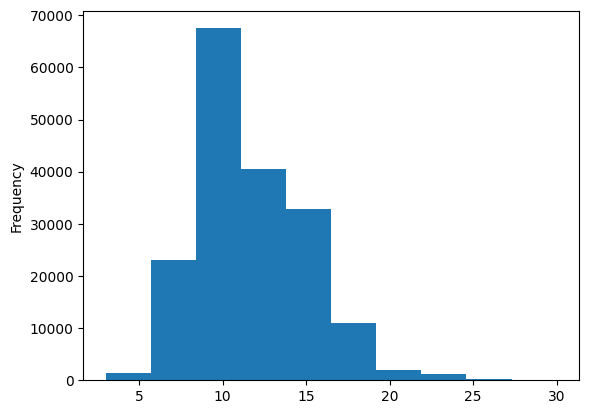

In [21]:
# Let's check the length of different lines
train_df.total_lines.plot.hist();

In [22]:
# Convert abstract text lines into lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

In [23]:
# View the 10 lines of training sentences
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

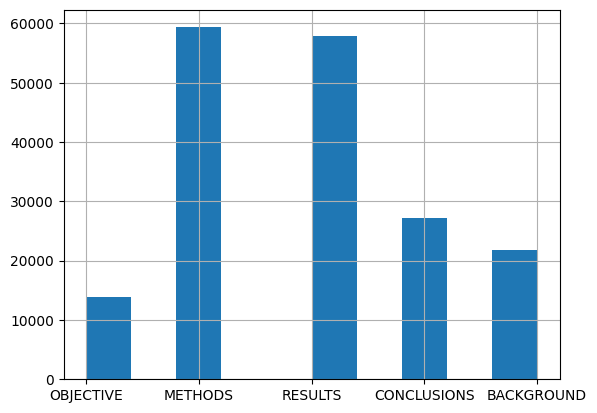

In [24]:
train_df["target"].hist();

In [25]:
train_df["target"].to_numpy()

array(['OBJECTIVE', 'METHODS', 'METHODS', ..., 'RESULTS', 'CONCLUSIONS',
       'CONCLUSIONS'], dtype=object)

# Data Preprocessing

### One Hot Encoder

In [26]:
# import torch

# # Sample array
# categories = train_df["target"].to_numpy()

# # Convert the array to a tensor of unique category indices
# category_to_index = {category: idx for idx, category in enumerate(set(categories))}
# indices = torch.tensor([category_to_index[category] for category in categories])

# # One-hot encode the indices
# one_hot_encoded = torch.nn.functional.one_hot(indices, num_classes=len(category_to_index))

# print(category_to_index)
# print(one_hot_encoded[:10])


In [27]:
train_df["target"].to_numpy().reshape(-1, 1)

array([['OBJECTIVE'],
       ['METHODS'],
       ['METHODS'],
       ...,
       ['RESULTS'],
       ['CONCLUSIONS'],
       ['CONCLUSIONS']], dtype=object)

In [28]:
# One hot encode labels of train data
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False) # we want non-sparse matrix as tensorflow is incompatible with sparse matrix
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))

# Check out our one hot encoded labels
train_labels_one_hot[:10], val_labels_one_hot[:10], test_labels_one_hot[:10]

(array([[0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.]]),
 array([[1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.]]),
 array([[1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.]]))

### Label Encoder

In [29]:
# Extract label {"target" columns} and encode them into integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_label_encoded = label_encoder.transform(test_df["target"].to_numpy())

# Check out training labels
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

# Model_0: Navie Bayes and Tf-IDF vectorizer

Bayes' Theorem:
$$
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
$$

where:

- $P(A|B)$: Posterior probability of event $A$ given that event $B$ has occurred.
- $P(B|A)$: Likelihood of event $B$ given that event $A$ has occurred.
- $P(A)$: Prior probability of event $A$.
- $P(B)$: Prior probability of event $B$.

- **Posterior Probability ($P(A|B)$)**: Probability of event $A$ occurring given that event $B$ has occurred.
- **Likelihood ($P(B|A)$)**: Probability of observing event $B$ given that $A$ is true.
- **Prior Probability ($P(A)$)**: Initial belief about the probability of event $A$ before any evidence $B$ is taken into account.
- **Evidence ($P(B)$)**: Total probability of observing event $B$, summed over all possible occurrences.

Bayes' Theorem helps us update our initial beliefs (priors) based on new evidence (likelihoods) to obtain a more accurate posterior probability.


Naïve Bayes Formula:
$$
P(C_k | x_1, x_2, \ldots, x_n) = \frac{P(C_k) \cdot P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot \ldots \cdot P(x_n | C_k)}{P(x_1, x_2, \ldots, x_n)}
$$

where:

$$
P(C_k | x_1, x_2, \ldots, x_n) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)
$$

- $P(C_k)$: Prior probability of class $C_k$.
- $P(x_i | C_k)$: Likelihood of feature $x_i$ given class $C_k$.
- $P(x_1, x_2, \ldots, x_n)$: Marginal probability of the predictors (a normalizing constant for all classes).


`Multinomial Naïve Bayes Formula`

Given a document $d$ represented by the vector of word counts $\mathbf{x} = (x_1, x_2, \ldots, x_n)$ and a class $C_k$:

$$
P(C_k | \mathbf{x}) = \frac{P(C_k) \cdot P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot \ldots \cdot P(x_n | C_k)}{P(\mathbf{x})}
$$

where:

- $P(C_k)$: Prior probability of class $C_k$.
- $P(x_i | C_k)$: Likelihood of feature $x_i$ given class $C_k$.
- $P(\mathbf{x})$: Prior probability of the feature vector $\mathbf{x}$.

---

`Simplified Formula for Classification of Multinomial NB`

Since $P(\mathbf{x})$ is constant for all classes:

$$
P(C_k | \mathbf{x}) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)
$$

---

` Explanation of Multinomial NB`

Multinomial Naïve Bayes is suitable for discrete data such as word counts in text classification. It uses the multinomial distribution to model the distribution of features and assumes that the features are conditionally independent given the class label.


### Term Frequency-Inverse Document Frequency (TF-IDF)

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

where:

$$
\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

$$
\text{IDF}(t) = \log \left( \frac{1 + N}{1 + \text{DF}(t)} \right)
$$

- $t$: Term (word)
- $d$: Document
- $N$: Total number of documents
- $\text{DF}(t)$: Number of documents containing the term $t$


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer #Convert a collection of raw documents to a matrix of TF-IDF features or vectors.
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create tokenization and modelling Pipeline
model_0 = Pipeline([
    # Tuple
    ("tfidf", TfidfVectorizer()), # Convert words to number using tfidf
    ("clf", MultinomialNB()) # model the text
])

# Fit the pipeline to the training data
model_0.fit(X=train_sentences, y=train_labels_encoded) # multinomialNB doesnot support one hot encoded, just label encoder

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [31]:
baseline_score = model_0.score(val_sentences, val_labels_encoded)
print(f"Our baseline model achieves an accuracy of: {baseline_score*100:.2f}%")

Our baseline model achieves an accuracy of: 72.18%


In [32]:
# function to show true and predicted value in table
def create_table(true_labels, predicted_labels):
  """
  Creates a pandas DataFrame with columns for true labels, predicted labels, and whether they match.

  Args:
      true_labels (list): List of true labels.
      predicted_labels (list): List of predicted labels.

  Returns:
      pandas.DataFrame: DataFrame containing true labels,
      predicted labels, and a boolean column indicating if they match.
  """

  df = pd.DataFrame({
      "true_label": true_labels,
      "predicted_label": predicted_labels,
      "match": true_labels == predicted_labels
  })

  return df

In [33]:
# Make predictions using our baseline model
baseline_preds = model_0.predict(val_sentences)
baseline_preds, val_labels_encoded

(array([4, 1, 3, ..., 4, 4, 1]), array([0, 0, 3, ..., 4, 1, 1]))

In [34]:
# Get class names and number of classes from label encoder instances
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
print(f"num_classes:{num_classes} and class_names: {class_names}")
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

num_classes:5 and class_names: ['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']
{'BACKGROUND': np.int64(0), 'CONCLUSIONS': np.int64(1), 'METHODS': np.int64(2), 'OBJECTIVE': np.int64(3), 'RESULTS': np.int64(4)}


In [35]:
create_table(val_labels_encoded, baseline_preds).head()

,true_label,predicted_label,match
0,0,4,False
1,0,1,False
2,3,3,True
3,2,2,True
4,2,2,True


# Createing an evaluation function for our model experiments

We could evaluate all our model's predictions with different matrix every time, this can be easily fixed with function.

Let's create one to compare our model's predictions with the truth labels using the functions.
* Accuracy
* Precision
* Recall
* F1-score

Deep overview for many model evaluation use: sklearn: https://scikit-learn.org/stable/modules/model_evaluation.html

$ \text{Accuracy} = \frac{\sum_{i=1}^{N} \mathbb{1}(\hat{y}_i = y_i)}{N} \times 100 $



| **Metric**     | **Formula** |
|---------------|------------|
| **Accuracy**  | $$ Accuracy = \frac{True\ Positives + True\ Negatives}{True\ Positives + True\ Negatives + False\ Positives + False\ Negatives} \times 100 $$ |
| **Precision** | $$ Precision = \frac{True\ Positives}{True\ Positives + False\ Positives} \times 100 $$ |
| **Recall**    | $$ Recall = \frac{True\ Positives}{True\ Positives + False\ Negatives} \times 100 $$ |
| **F1 Score**  | $$ F1\ Score = \frac{2 \times Precision \times Recall}{Precision + Recall} $$ |


-----------------------------------------------------


| **Metric**     | **Formula** |
|---------------|------------|
| **Accuracy**  | $$ Accuracy = \frac{Correct\ Predictions}{Total\ Predictions} \times 100 $$ |
| **Precision** | $$ Precision = \frac{Relevant\ Predictions}{Total\ Predicted\ Positive} \times 100 $$ |
| **Recall**    | $$ Recall = \frac{Relevant\ Predictions}{Total\ Actual\ Positive} \times 100 $$ |
| **F1 Score**  | $$ F1\ Score = \frac{2 \times Precision \times Recall}{Precision + Recall} $$ |


------------------------------------------------------



| **Metric**     | **Formula** |
|---------------|------------|
| **Accuracy**  | $$ Accuracy = \frac{\sum_{i=1}^{n} \mathbb{1}(\hat{y}_i = y_i)}{n} \times 100 $$ |
| **Precision** | $$ Precision = \frac{\sum_{i=1}^{n} \mathbb{1}(\hat{y}_i = 1 \cap y_i = 1)}{\sum_{i=1}^{n} \mathbb{1}(\hat{y}_i = 1)} \times 100 $$ |
| **Recall**    | $$ Recall = \frac{\sum_{i=1}^{n} \mathbb{1}(\hat{y}_i = 1 \cap y_i = 1)}{\sum_{i=1}^{n} \mathbb{1}(y_i = 1)} \times 100 $$ |
| **F1 Score**  | $$ F1\ Score = \frac{2 \times Precision \times Recall}{Precision + Recall} $$ |




In [36]:
# Function to evalute: accuracy, precision, recall, f1-score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):
  """
  Calculate model accuracy, precision, recall and f1 score of a binary classification model.
  """

  # Calculate model accuracy
  model_accuracy = accuracy_score(y_true, y_pred) * 100
  # Calculate model precision, recall, f1-score using average = weighted average # weighted average is good for slight model imbalance like here
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

  model_results = {"accuracy": model_accuracy,
                   "precision": model_precision,
                   "recall": model_recall,
                   "f1": model_f1}

  return model_results

In [37]:
# Get baseline results
baseline_results = calculate_results(y_true = val_labels_encoded,
                                     y_pred = baseline_preds)

baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

# Text Vectorization and embeddings

## Text Vectorizer

In [38]:
# Each sentence length
sent_lens=[len(i.split()) for i in train_sentences]

# How long is each senctences in average
avg_sent_len = np.mean(sent_lens)
avg_sent_len
# seem no of token or words is 26

np.float64(26.338269273494777)

(array([4.2075e+04, 8.3771e+04, 3.6877e+04, 1.0945e+04, 3.9310e+03,
        1.4450e+03, 5.6000e+02, 2.2600e+02, 1.0100e+02, 4.5000e+01,
        2.0000e+01, 1.2000e+01, 9.0000e+00, 1.0000e+01, 6.0000e+00,
        2.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([  1.  ,  15.75,  30.5 ,  45.25,  60.  ,  74.75,  89.5 , 104.25,
        119.  , 133.75, 148.5 , 163.25, 178.  , 192.75, 207.5 , 222.25,
        237.  , 251.75, 266.5 , 281.25, 296.  ]),
 <BarContainer object of 20 artists>)

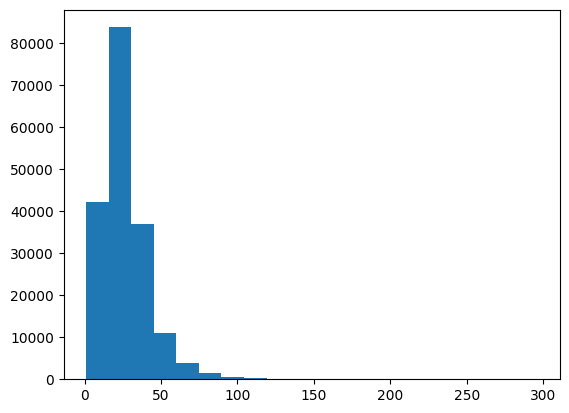

In [39]:
# What's the distribution look like?
import matplotlib.pyplot as plt
plt.hist(sent_lens, bins=20)

# vast majority of sentences are under 50 words

In [40]:
# How long of a sentences length coers 95% of examples? how long our max_lenght should be so it covers most of the sentences
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

# This is saying 95% of sentences are under 55

55

In [41]:
# Max sequence length in the training set
max(sent_lens)
# ridiculous to set max_length to 296
# best is 55 for performance without losing accuracy

296

In [102]:
import re
import torch
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# Configuration (match your TF setup)
max_vocab_length = 68000
max_length = 55  # output_seq_len from your analysis

# 1. Text preprocessing and tokenization
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

def tokenize(text):
    return preprocess_text(text).split()

# 2. Build vocabulary from training data
def build_vocab(text_list, max_tokens):
    special_tokens = ['<PAD>', '<UNK>']
    counter = Counter()

    for text in text_list:
        tokens = tokenize(text)
        counter.update(tokens)

    # Get most common tokens (excluding special tokens)
    vocab = special_tokens.copy()
    for token, _ in counter.most_common(max_tokens - len(special_tokens)):
        vocab.append(token)

    return {token: idx for idx, token in enumerate(vocab)}

# Build vocabulary (equivalent to adapt())
vocab = build_vocab(train_sentences, max_vocab_length)

# 3. Text-to-index conversion with padding/truncation
def text_to_indices(text):
    tokens = tokenize(text)
    indices = [vocab.get(token, 1) for token in tokens]  # 1 = <UNK>

    # Truncate or pad to max_length
    if len(indices) > max_length:
        indices = indices[:max_length]
    else:
        indices += [0] * (max_length - len(indices))  # 0 = <PAD>

    return torch.tensor(indices, dtype=torch.long)

# 4. Custom Dataset
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return text_to_indices(self.texts[idx])

# 4. Collate Function (unchanged)
def collate_fn(batch):
    lengths = torch.tensor([len(x) for x in batch], dtype=torch.long)
    padded_batch = torch.nn.utils.rnn.pad_sequence(
        batch,
        batch_first=True,
        padding_value=0  # Use 0 for <PAD>
    )
    return padded_batch, lengths

# 5. Create DataLoader
dataset = TextDataset(train_sentences)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Example usage
sample = next(iter(dataloader))
print(f"Batch shape: {sample[0].shape}")  # Should be (batch_size, max_length=55)

Batch shape: torch.Size([32, 55])


In [103]:
len(dataset), len(vocab), len(train_sentences)

(180040, 64847, 180040)

In [105]:
dataset[4]

tensor([ 151,   86,  213,  121,    2, 1361, 4675,    3, 6447, 5783, 1429,  203,
         119,  127,  646,  249, 7749,    4,    2,  332,    4,  516, 1740,    3,
         242, 1746, 1165, 6324,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0])

In [108]:
# Create single-sample batch
sample_sentence = "There's a flood in my street!"
sample_dataset = TextDataset([sample_sentence])
sample_loader = DataLoader(sample_dataset, batch_size=1, collate_fn=collate_fn)

# Get the batch
batch, lengths = next(iter(sample_loader))
print("Batch data:\n", batch)
print("Actual lengths:", lengths)

Batch data:
 tensor([[55634,     8,     1,     5, 25433, 10253,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0]])
Actual lengths: tensor([55])


In [110]:
import random
# Choose  a random sentence from the training dataset and tokenize it
random_sentence = random.choice(train_sentences)
print(f"The length of random sentence: {len(random_sentence)}")
print(f"Original text:\n {random_sentence}\
      \n\nVectorized version:")

sample_sentence = random_sentence
sample_dataset = TextDataset([sample_sentence])
sample_loader = DataLoader(sample_dataset, batch_size=1, collate_fn=collate_fn)

# Get the batch
batch, lengths = next(iter(sample_loader))
print("Batch data:\n", batch)
print("Actual lengths:", lengths)

The length of random sentence: 82
Original text:
 rtn # @ , blinded to group assignment , obtained post-procedure ti and td scores .      

Vectorized version:
Batch data:
 tensor([[37944,   586,     6,    13,  1408,   527,  5471,  6694,     3,  1993,
           119,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0]])
Actual lengths: tensor([55])


In [112]:
# Get vocabulary statistics (equivalent to TF's get_vocabulary())
def get_vocabulary_stats(vocab_dict, max_vocab_length=68000):
    # Reverse the vocab dict to get {index: word} mapping
    index_to_word = {idx: word for word, idx in vocab_dict.items()}

    # Get all words sorted by frequency (assuming vocab was built with most_common)
    all_words = [index_to_word.get(i, f"<RESERVED_{i}") for i in range(len(index_to_word))]

    # Most common words (first 5 after special tokens)
    top_5_words = all_words[2:7]  # Skip 0:<PAD>, 1:<UNK>

    # Least common words (last 5 in vocab)
    bottom_5_words = all_words[-5:]

    return all_words, top_5_words, bottom_5_words

# Get stats from our PyTorch vocab
rct_20k_text_vocab, top_5_words, bottom_5_words = get_vocabulary_stats(vocab)

print(f"Number of words in vocab: {len(rct_20k_text_vocab)}")
print(f"5 most common words: {top_5_words}")
print(f"5 least common words: {bottom_5_words}")

Number of words in vocab: 64847
5 most common words: ['the', 'and', 'of', 'in', 'to']
5 least common words: ['normophosphatemic', 'exceedthe', 'oflaboratory', 'inhibitioninduced', 'preciseivus']


## Embedding

In [113]:
import torch.nn as nn

# PyTorch Embedding layer equivalent
token_embed = nn.Embedding(
    num_embeddings=len(rct_20k_text_vocab),  # 68000
    embedding_dim=128,
    padding_idx=0  # Equivalent to mask_zero=True (ignores padding index during updates or training)
)

print(token_embed)

Embedding(64847, 128, padding_idx=0)


In [133]:
# for visualizaion only one random sentence

# Get a random sentence from the training set
random_sentence = random.choice(train_sentences)
print(f"Original text:\n {random_sentence}\n\n")

# Embed the random sentence (turn it into dense vector of fixed size)
# sample_embed = token_embed(text_vectorizer([random_sentence]))

sample_embed = token_embed(TextDataset([sample_sentence])[0].unsqueeze(dim=0)) # unsqueeze just to add batch dimension

print(f"Sentence after embedding:\n {sample_embed}\n\n")
print(f"Shape of embedded sentence: {sample_embed.shape}")

Original text:
 the c allele was associated with lower triglycerides , and this association was modulated by fat intake .


Sentence after embedding:
 tensor([[[-0.5554, -0.2002,  0.5335,  ...,  1.1263,  0.0046,  0.4209],
         [ 0.1861, -0.4998, -1.9823,  ...,  1.0328, -0.1355, -0.9966],
         [ 0.5194, -0.0623,  0.6068,  ...,  1.1700, -2.0556,  0.1661],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
       grad_fn=<EmbeddingBackward0>)


Shape of embedded sentence: torch.Size([1, 55, 128])


In [134]:
# Check out a single token's embedding for the first word of our sentence e.g. the
print(f"Original text:\n {random_sentence}\n\n")
print(f"First word :\n {random_sentence.split(' ', 1)[0]}\n\n")
print(f" Embedding values of single First word ({random_sentence.split(' ', 1)[0]}) in sentences are: {sample_embed[0][0]}\n\n")
print(f"Shape of each word (here word: {random_sentence.split(' ', 1)[0]}) is: {sample_embed[0][0].shape}")

Original text:
 the c allele was associated with lower triglycerides , and this association was modulated by fat intake .


First word :
 the


 Embedding values of single First word (the) in sentences are: tensor([-0.5554, -0.2002,  0.5335, -0.2605, -0.6283, -0.9017,  1.4411, -1.2296,
         0.4534,  2.1584,  0.2669,  2.8942, -0.5552, -0.2087,  1.3474,  0.5561,
         1.6149, -0.1549, -0.5121,  0.0770, -0.1206,  0.1347,  0.9566, -0.3103,
         1.1807, -0.0838,  1.0648,  0.5704, -2.1441,  0.6472, -1.3234, -0.0552,
        -0.1208,  0.5342, -0.0955, -0.3948, -1.2579,  1.0193, -2.1010, -0.1871,
        -2.6524,  0.4801, -0.0826,  0.7803,  0.1970, -0.2851,  0.2780, -0.8693,
         0.3400, -0.9940,  0.4024, -1.3505, -0.4246,  0.3793, -1.1345, -0.9779,
        -0.2989, -2.5349, -0.4465,  1.9169, -1.7139, -0.1135,  1.4561, -1.0029,
         0.0264, -0.0518,  0.2049, -2.0579,  1.5927, -0.0196,  0.0868, -1.3246,
         0.3114,  1.8507,  1.6207,  0.4563, -0.9593, -0.1859,  1.8994,  1